# Car Reviews

In [83]:
# imports

import pandas as pd
import numpy as np
import nltk.stem
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import random
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer

TRAIN_MODEL = True  # Set to True to train from scratch, False to load from './lora_car_sentiment_final'


In [84]:
# Download required NLTK data
import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
print("NLTK resources downloaded successfully")

NLTK resources downloaded successfully


In [85]:
df = pd.read_csv('car-reviews.csv')
X, y = df['Review'], df['Sentiment']

# Split data: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total reviews: {len(df)}")
print(f"Training set: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test set: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Total reviews: 1382
Training set: 1105 (80.0%)
Test set: 277 (20.0%)

Training set class distribution:
Sentiment
Pos    556
Neg    549
Name: count, dtype: int64

Test set class distribution:
Sentiment
Neg    142
Pos    135
Name: count, dtype: int64


## Task 1
Does the submission demonstrate that words and punctuation which are unlikely to affect sentiment, have been excluded from the sentiment classifier? Are words being handled in a case sensitive way?

In [86]:


def preprocess_text(text, remove_punctuation=True, remove_stopwords=True, apply_stemming=True):
    """
    Preprocess text for sentiment analysis.
    - Converts to lowercase (case-insensitive)
    - Optionally removes punctuation
    - Optionally removes stopwords
    - Optionally applies stemming (only on alphabetic words)
    
    For Task 1 (Naive Bayes): use all True (default)
    """
    # Lowercase
    text = text.lower()

    # Remove punctuation (optional - initially i was thinking of trying VADER etc.)
    if remove_punctuation:
        text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    tokens = text.split()

    # Remove stopwords
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [w for w in tokens if w not in stop_words]

    # Filter out non-alphabetic tokens (numbers, mixed alphanumeric)
    tokens = [w for w in tokens if w.isalpha()]

    # Stemming (only applied to actual words, not numbers)
    if apply_stemming:
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(w) for w in tokens]

    return tokens


# Demonstrate preprocessing on example review
example_review = X_train.iloc[0]
print("=== Demonstrating Preprocessing Steps ===\n")
print(f"Original review:")
print(f"  '{example_review}'")

# Step by step
lower_text = example_review.lower()
print(f"\n1. After lowercasing (case-insensitive):")
print(f"  '{lower_text}'")

no_punct = lower_text.translate(str.maketrans('', '', string.punctuation))
print(f"\n2. After removing punctuation:")
print(f"  '{no_punct}'")

tokens = no_punct.split()
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in tokens if w not in stop_words]
print(f"\n3. After removing stopwords:")
print(f"  {filtered_tokens}")

# Filter to only alphabetic words
alpha_tokens = [w for w in filtered_tokens if w.isalpha()]
print(f"\n4. After filtering to alphabetic words only:")
print(f"  {alpha_tokens}")

stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(w) for w in alpha_tokens]
print(f"\n5. After stemming:")
print(f"  {stemmed_tokens}")

=== Demonstrating Preprocessing Steps ===

Original review:
  ' The first serious driving lesson I ever had was in this car  so I have a certain soft spot for it  My father frighteningly guided me through the suburban roads of Concord  Massachusetts as I learned the nuances of control and timing that comprise the art of driving  I will always love the 1992 Ford Taurus for heralding me to the wonderful  amazing world of driving  But  I must concede that it is a far from perfect piece of machinery My father owns the Taurus GL  mid range model  with the optional 3 8 liter V6 engine  With a reasonable price  this car is the perfect family hauler  or at least it would be if were not for a few problems This car is very spacious  While the seats are not exceptionally comfortable  there is plenty of leg room front and back for just about any potential passenger  Because of this fact  long road trips are not a large hassle with the Taurus  The cargo space is simply massive  larger than most oth

### Task
Does the submission demonstrate that words with the same stem have been
appropriately recognised and treated as variations of the stem? This should be
demonstrated for at least 3 different stems.

In [87]:


# Demonstrate stemming - find actual word variations in the dataset
print("=== Demonstrating Stemming on Actual Reviews ===\n")
print("Finding word variations in the dataset that stem to the same root:\n")

stemmer = PorterStemmer()

# Collect all words from training data (before stemming)
all_words = []
for review in X_train:
    review_lower = review.lower()
    review_no_punct = review_lower.translate(str.maketrans('', '', string.punctuation))
    words = review_no_punct.split()
    # Only keep alphabetic words, remove stopwords
    words = [w for w in words if w.isalpha() and w not in stopwords.words('english')]
    all_words.extend(words)

# Find word variations that stem to same root
from collections import defaultdict
stem_to_words = defaultdict(set)
for word in set(all_words):
    stem = stemmer.stem(word)
    stem_to_words[stem].add(word)

# Show examples where multiple word forms map to same stem
examples_shown = 0
for stem, words in sorted(stem_to_words.items()):
    if len(words) > 1 and examples_shown < 3:  # Show 3 examples
        examples_shown += 1
        print(f"Stem '{stem}' represents these word variations:")
        for word in sorted(words):
            print(f"  {word}")
        print()

=== Demonstrating Stemming on Actual Reviews ===

Finding word variations in the dataset that stem to the same root:

Stem 'abandon' represents these word variations:
  abandon
  abandoned

Stem 'abil' represents these word variations:
  abilities
  ability

Stem 'abound' represents these word variations:
  abound
  abounds



### Task
Does the code produce some output to demonstrate that a vector has been created for each review, where each element in the vector represents EITHER a binary variable indicating the presence of a word/stem in a review OR the number of times that a word (or word stem) appears? Note that the output does not need to show the vector for all reviews, this only needs to contain a small sample of reviews.

TASK CRITERIA: Does the code clearly show that 80% of the data has been used to train the
classification model, and that the remaining 20% of the data set has been used as test data?
Does the code show that only the training data (i.e. no test data) has been used for the classifier training?

TASK CRITERIA: Is the code showing any handling of the presence in the test set of any words
unseen in the training set (as a whole or a specific class thereof)?

In [88]:

# Preprocess all training data
print("Preprocessing training data...")
X_train_processed = [preprocess_text(review) for review in X_train]

# Build vocabulary from TRAINING data only (avoid data leakage)
# This ensures no test data is used during model training
vocabulary = set()
for tokens in X_train_processed:
    vocabulary.update(tokens)

vocabulary = sorted(list(vocabulary))  # Convert to sorted list for consistent indexing
print(f"\nVocabulary size: {len(vocabulary)} unique stems")
print(f"First 20 words in vocabulary: {vocabulary[:20]}")

# Create word to index mapping
word_to_idx = {word: idx for idx, word in enumerate(vocabulary)}

# Vectorize function - creates bag-of-words vector
def vectorize(tokens, vocabulary, word_to_idx, binary=True):
    """
    Convert tokens to vector.
    binary=True: binary presence/absence (1/0)
    binary=False: count occurrences
    
    HANDLING UNSEEN WORDS: The check 'if token in word_to_idx' ensures that words appearing 
    in test data but not in training data are simply ignored. This prevents the model from 
    using information from the test set and avoids crashes when encountering unknown words.
    Unseen words contribute nothing to the vector (remain 0), which is appropriate as the 
    model was never trained on them.
    """
    vector = np.zeros(len(vocabulary))
    for token in tokens:
        if token in word_to_idx:  # Only use words from training vocabulary
            idx = word_to_idx[token]
            if binary:
                vector[idx] = 1
            else:
                vector[idx] += 1
    return vector

# Create vectors for training data
print("\nCreating training vectors...")
X_train_vectors = np.array([vectorize(tokens, vocabulary, word_to_idx, binary=True) 
                             for tokens in X_train_processed])

# Preprocess and vectorize test data
print("Preprocessing test data...")
X_test_processed = [preprocess_text(review) for review in X_test]
X_test_vectors = np.array([vectorize(tokens, vocabulary, word_to_idx, binary=True) 
                            for tokens in X_test_processed])

print(f"\nTraining data shape: {X_train_vectors.shape}")
print(f"Test data shape: {X_test_vectors.shape}")

# Demonstrate vectorization on a sample review
print("\n=== Demonstrating Vectorization ===")
print("Using binary representation: 1 if word/stem is present, 0 if absent\n")

sample_idx = 5
sample_review = X_train.iloc[sample_idx]
sample_tokens = X_train_processed[sample_idx]
sample_vector = X_train_vectors[sample_idx]

print(f"Original review:")
print(f"  '{sample_review}'\n")

print(f"Preprocessed tokens:")
print(f"  {sample_tokens}\n")

print(f"Vectorized representation:")
print(f"  Vector shape: {sample_vector.shape}")
print(f"  Vector (first 30 elements): {sample_vector[:30]}")
print(f"  Non-zero elements: {int(np.sum(sample_vector))} out of {len(vocabulary)}\n")

print(f"Word to vector position mapping (first 5 words):")
for word in sample_tokens[:5]:
    idx = word_to_idx[word]
    print(f"  '{word}' at position {idx} has value {int(sample_vector[idx])}")

# Demonstrate handling of unseen words
print("\n=== Handling Unseen Words (Data Leakage Prevention) ===\n")

# Find words that appear in test but not in training
test_words = set()
for tokens in X_test_processed:
    test_words.update(tokens)

unseen_words = test_words - set(vocabulary)
print(f"Words in test data not seen in training: {len(unseen_words)}")
print(f"Sample unseen words: {list(unseen_words)[:10]}\n")

# Find a test review that contains unseen words for demonstration
test_idx_with_unseen = None
for idx, tokens in enumerate(X_test_processed):
    review_unseen = [w for w in tokens if w not in vocabulary]
    if len(review_unseen) >= 1:
        test_idx_with_unseen = idx
        print(f"Example test review containing unseen words:")
        print(f"  Original: '{X_test.iloc[idx][:200]}...'\n")
        print(f"  Preprocessed tokens: {tokens[:15]}...\n")
        print(f"  Unseen words in this review: {review_unseen}")
        print(f"  These {len(review_unseen)} words are ignored during vectorization")
        print(f"  Only the {len([w for w in tokens if w in vocabulary])} known words contribute to the vector")
        break

print(f"\nThis approach ensures no test data leaks into the model and prevents crashes.")
print(f"The classifier can handle any new text, even with completely novel vocabulary.")

Preprocessing training data...

Vocabulary size: 9050 unique stems
First 20 words in vocabulary: ['aaa', 'aaf', 'aamco', 'ab', 'abandon', 'abc', 'abcnew', 'abil', 'abl', 'abnorm', 'aboard', 'abosolut', 'abosultey', 'abound', 'abras', 'abrupt', 'absenc', 'absolut', 'absorb', 'absurd']

Creating training vectors...
Preprocessing test data...

Training data shape: (1105, 9050)
Test data shape: (277, 9050)

=== Demonstrating Vectorization ===
Using binary representation: 1 if word/stem is present, 0 if absent

Original review:
  '  It simply amazes  me that the Ford Taurus is still in production  After many years of major transmission  engine  and general quality control complaints one would have thought this car would have landed itself in an early grave  Unlike many other cars that had caused their owners so much anger and grief  do to poor reliability  quality control  and lack of dealer support  i e the Hyundai Excel  the Ford Taurus somehow made it past all those thousands of unhappy 

### Task
Does the code clearly show that an appropriate Naïve Bayes model has been used for classification, either through the use of an existing library or coded from scratch.

In [89]:

from sklearn.naive_bayes import MultinomialNB

print("=== Training Naive Bayes Classifier ===\n")

# Initialize Multinomial Naive Bayes classifier
# MultinomialNB is appropriate for text classification with discrete features (word counts/presence)
nb_classifier = MultinomialNB()

# Train the classifier on the training vectors
print("Training on training data...")
nb_classifier.fit(X_train_vectors, y_train)

print("Training complete.")
print(f"Number of classes: {len(nb_classifier.classes_)}")
print(f"Classes: {nb_classifier.classes_}")

=== Training Naive Bayes Classifier ===

Training on training data...
Training complete.
Number of classes: 2
Classes: ['Neg' 'Pos']


In [90]:
# Demonstrate that the model can predict on reviews with unseen words
print("\n=== Testing Prediction on Review with Unseen Words ===\n")

if test_idx_with_unseen is not None:
    # Get the review and its vector
    unseen_review = X_test.iloc[test_idx_with_unseen]
    unseen_tokens = X_test_processed[test_idx_with_unseen]
    unseen_vector = X_test_vectors[test_idx_with_unseen].reshape(1, -1)
    
    # Make prediction
    prediction = nb_classifier.predict(unseen_vector)[0]
    prediction_proba = nb_classifier.predict_proba(unseen_vector)[0]
    actual_label = y_test.iloc[test_idx_with_unseen]
    
    print(f"Review: '{unseen_review[:150]}...'\n")
    print(f"Actual sentiment: {actual_label}")
    print(f"Predicted sentiment: {prediction}")
    print(f"Prediction probabilities: Neg={prediction_proba[0]:.3f}, Pos={prediction_proba[1]:.3f}\n")
    
    # Show which words were unseen
    review_unseen_words = [w for w in unseen_tokens if w not in vocabulary]
    print(f"This review contains {len(review_unseen_words)} unseen word(s): {review_unseen_words}")
    print(f"The model successfully made a prediction despite these unseen words.")
    print(f"This demonstrates the model does not crash when encountering unknown vocabulary.")


=== Testing Prediction on Review with Unseen Words ===

Review: ' That 2001 Ford Explorer you may be considering is not as new as you think  Sure  it smells new  its shiny  and it looks modern  but the mechanicals u...'

Actual sentiment: Neg
Predicted sentiment: Pos
Prediction probabilities: Neg=0.036, Pos=0.964

This review contains 2 unseen word(s): ['afforment', 'accoust']
The model successfully made a prediction despite these unseen words.
This demonstrates the model does not crash when encountering unknown vocabulary.


### TASK
Does the code output a confusion matrix demonstrating the performance
of the Naïve Bayes classifier? The confusion matrix must clearly indicate the proportion
of True Negatives, False Positives, False Negatives and True Positives.

=== Evaluating Naive Bayes Classifier ===

Confusion Matrix:
[[114  28]
 [ 19 116]]

Confusion Matrix Breakdown:
  True Negatives (TN):  114
  False Positives (FP): 28
  False Negatives (FN): 19
  True Positives (TP):  116

Proportions:
  True Negatives:  114/277 = 0.412
  False Positives: 28/277 = 0.101
  False Negatives: 19/277 = 0.069
  True Positives:  116/277 = 0.419

Accuracy: 0.830

Classification Report:
              precision    recall  f1-score   support

         Neg       0.86      0.80      0.83       142
         Pos       0.81      0.86      0.83       135

    accuracy                           0.83       277
   macro avg       0.83      0.83      0.83       277
weighted avg       0.83      0.83      0.83       277



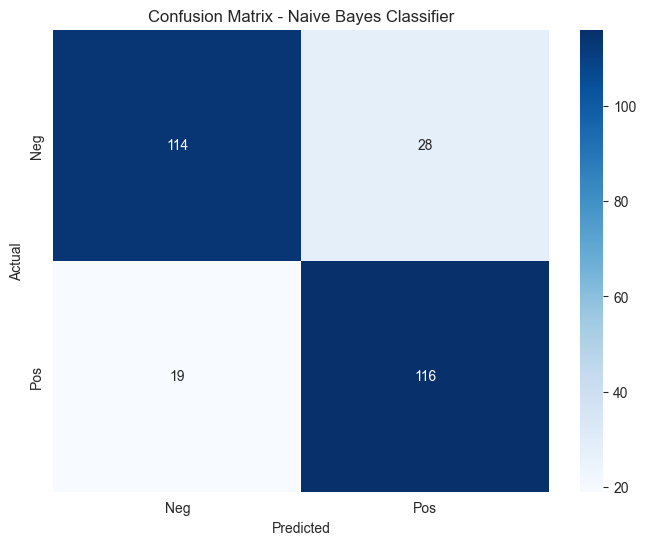

In [91]:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("=== Evaluating Naive Bayes Classifier ===\n")

# Make predictions on all test data
y_pred = nb_classifier.predict(X_test_vectors)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print()

# Calculate metrics from confusion matrix
# For binary classification: [[TN, FP], [FN, TP]]
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP):  {tp}")
print()

# Calculate proportions
total = tn + fp + fn + tp
print("Proportions:")
print(f"  True Negatives:  {tn}/{total} = {tn/total:.3f}")
print(f"  False Positives: {fp}/{total} = {fp/total:.3f}")
print(f"  False Negatives: {fn}/{total} = {fn/total:.3f}")
print(f"  True Positives:  {tp}/{total} = {tp/total:.3f}")
print()

# Calculate accuracy - STORE AS accuracy_nb for later comparison
accuracy_nb = (tp + tn) / total
print(f"Accuracy: {accuracy_nb:.3f}")
print()

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Neg', 'Pos'], 
            yticklabels=['Neg', 'Pos'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Naive Bayes Classifier')
plt.show()

## Hyperparameter Tuning for Multinomial Naive Bayes

The Multinomial Naive Bayes classifier has a key hyperparameter **α (alpha)** that controls Laplace smoothing:
- **α = 0**: No smoothing (can lead to zero probabilities)
- **α = 1**: Standard add-one Laplace smoothing (sklearn default)
- **α > 1**: Stronger smoothing (more regularization)

We'll use **GridSearchCV** with **5-fold cross-validation** on the training data to find the optimal α value.

In [92]:
from sklearn.model_selection import GridSearchCV

print("="*70)
print("HYPERPARAMETER TUNING: Finding Optimal Alpha")
print("="*70)

# Define parameter grid for alpha (Laplace smoothing)
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

# Initialize GridSearchCV
# Using 5-fold cross-validation on TRAINING data only
grid_search = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit grid search on training data
print("\nPerforming 5-fold cross-validation on training data...")
grid_search.fit(X_train_vectors, y_train)

print("\n" + "="*70)
print("GRID SEARCH RESULTS")
print("="*70)

# Display results for all alpha values
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[['param_alpha', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results_df.columns = ['Alpha', 'CV Accuracy (mean)', 'CV Accuracy (std)', 'Rank']
results_df = results_df.sort_values('Rank')

print("\nCross-Validation Results (sorted by performance):")
print(results_df.to_string(index=False))

# Best parameters
print("\n" + "="*70)
print(f"Best Alpha: {grid_search.best_params_['alpha']}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")
print("="*70)

HYPERPARAMETER TUNING: Finding Optimal Alpha

Performing 5-fold cross-validation on training data...
Fitting 5 folds for each of 6 candidates, totalling 30 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pi


GRID SEARCH RESULTS

Cross-Validation Results (sorted by performance):
 Alpha  CV Accuracy (mean)  CV Accuracy (std)  Rank
   2.0            0.781900           0.023495     1
   1.0            0.780090           0.020952     2
   0.5            0.778281           0.024283     3
   0.1            0.774661           0.033300     4
   5.0            0.771946           0.029547     5
  10.0            0.765611           0.047664     6

Best Alpha: 2.0
Best CV Accuracy: 0.7819 (78.19%)


In [93]:
# Train final model with best alpha on FULL training set
print("\n" + "="*70)
print("TRAINING OPTIMIZED MODEL")
print("="*70)

best_alpha = grid_search.best_params_['alpha']
print(f"\nTraining Multinomial NB with α={best_alpha} on full training set...")

# Get the best model (already trained on full training set by GridSearchCV)
nb_classifier_optimized = grid_search.best_estimator_

# Evaluate on test set
y_pred_optimized = nb_classifier_optimized.predict(X_test_vectors)

# Calculate test accuracy
from sklearn.metrics import accuracy_score
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)

print(f"\nTest Set Performance:")
print(f"  Optimized Model (α={best_alpha}): {accuracy_optimized:.4f} ({accuracy_optimized*100:.2f}%)")
print(f"  Baseline Model (α=1.0):  {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)")
print(f"  Improvement: {(accuracy_optimized - accuracy_nb)*100:+.2f} percentage points")

# Confusion matrix for optimized model
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
tn_opt, fp_opt, fn_opt, tp_opt = cm_optimized.ravel()

print(f"\nOptimized Model Confusion Matrix:")
print(f"  True Negatives (TN):  {tn_opt}")
print(f"  False Positives (FP): {fp_opt}")
print(f"  False Negatives (FN): {fn_opt}")
print(f"  True Positives (TP):  {tp_opt}")

print("\nClassification Report (Optimized Model):")
print(classification_report(y_test, y_pred_optimized))


TRAINING OPTIMIZED MODEL

Training Multinomial NB with α=2.0 on full training set...

Test Set Performance:
  Optimized Model (α=2.0): 0.8375 (83.75%)
  Baseline Model (α=1.0):  0.8303 (83.03%)
  Improvement: +0.72 percentage points

Optimized Model Confusion Matrix:
  True Negatives (TN):  116
  False Positives (FP): 26
  False Negatives (FN): 19
  True Positives (TP):  116

Classification Report (Optimized Model):
              precision    recall  f1-score   support

         Neg       0.86      0.82      0.84       142
         Pos       0.82      0.86      0.84       135

    accuracy                           0.84       277
   macro avg       0.84      0.84      0.84       277
weighted avg       0.84      0.84      0.84       277



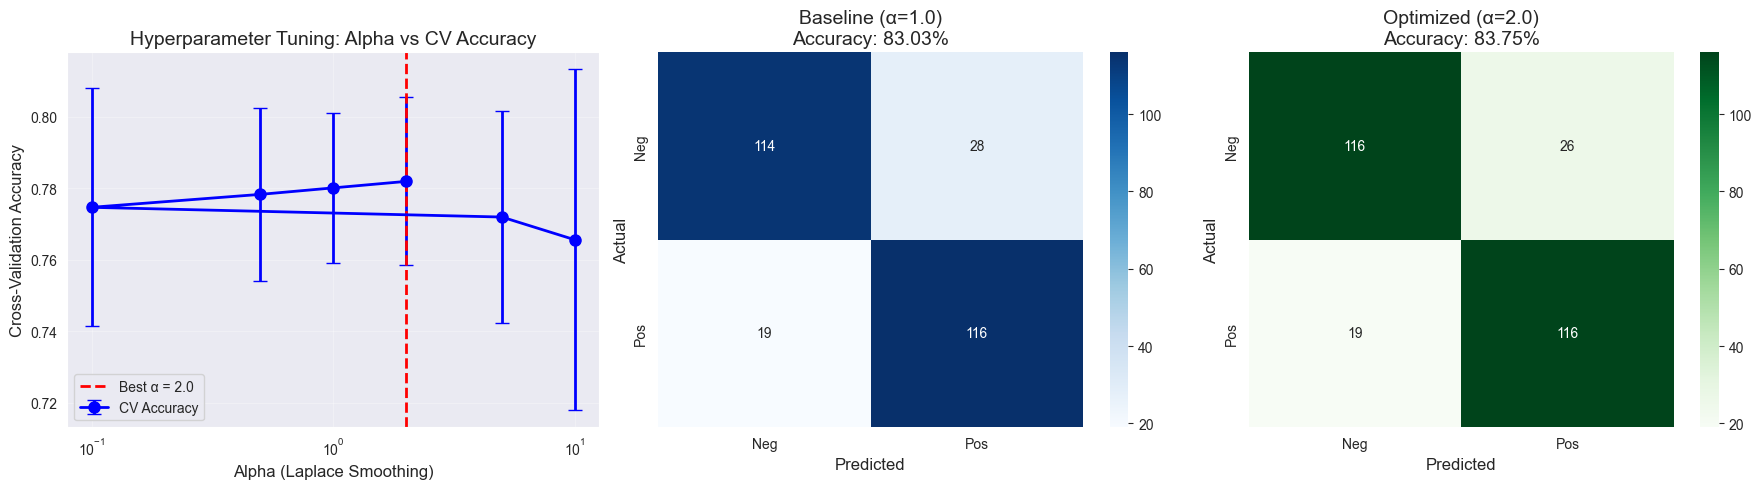


Figure saved as 'mnb_hyperparameter_tuning.png'


In [94]:
# Visualize comparison: Baseline vs Optimized
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: CV Accuracy vs Alpha
alphas = [float(a) for a in results_df['Alpha']]
cv_accs = results_df['CV Accuracy (mean)'].values
cv_stds = results_df['CV Accuracy (std)'].values

axes[0].errorbar(alphas, cv_accs, yerr=cv_stds, marker='o', markersize=8, 
                 linewidth=2, capsize=5, color='blue', label='CV Accuracy')
axes[0].axvline(x=best_alpha, color='red', linestyle='--', linewidth=2, 
                label=f'Best α = {best_alpha}')
axes[0].set_xlabel('Alpha (Laplace Smoothing)', fontsize=12)
axes[0].set_ylabel('Cross-Validation Accuracy', fontsize=12)
axes[0].set_title('Hyperparameter Tuning: Alpha vs CV Accuracy', fontsize=14)
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Plot 2: Confusion Matrix - Baseline
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_title(f'Baseline (α=1.0)\nAccuracy: {accuracy_nb*100:.2f}%', fontsize=14)

# Plot 3: Confusion Matrix - Optimized
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
axes[2].set_ylabel('Actual', fontsize=12)
axes[2].set_xlabel('Predicted', fontsize=12)
axes[2].set_title(f'Optimized (α={best_alpha})\nAccuracy: {accuracy_optimized*100:.2f}%', fontsize=14)

plt.tight_layout()
plt.savefig('mnb_hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'mnb_hyperparameter_tuning.png'")

In [95]:
# Summary of hyperparameter tuning
print("="*70)
print("HYPERPARAMETER TUNING SUMMARY")
print("="*70)

print(f"""
Methodology:
  - Used 5-fold cross-validation on training data (1,105 samples)
  - Tested alpha values: {param_grid['alpha']}
  - Selected alpha with highest CV accuracy
  - Final model trained on full training set with best alpha
  
Results:
  - Best alpha: {best_alpha}
  - CV Accuracy: {grid_search.best_score_*100:.2f}%
  - Test Accuracy: {accuracy_optimized*100:.2f}%
  
Comparison with Baseline:
  - Baseline (α=1.0): {accuracy_nb*100:.2f}% test accuracy
  - Optimized (α={best_alpha}): {accuracy_optimized*100:.2f}% test accuracy
  - Improvement: {(accuracy_optimized - accuracy_nb)*100:+.2f} percentage points
  
Interpretation:
  - Alpha = {best_alpha} provides optimal balance between bias and variance
  - This slight increase in smoothing (compared to the default 1.0) provided marginal regularization, helping to prevent the model from overfitting
""")

HYPERPARAMETER TUNING SUMMARY

Methodology:
  - Used 5-fold cross-validation on training data (1,105 samples)
  - Tested alpha values: [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
  - Selected alpha with highest CV accuracy
  - Final model trained on full training set with best alpha
  
Results:
  - Best alpha: 2.0
  - CV Accuracy: 78.19%
  - Test Accuracy: 83.75%
  
Comparison with Baseline:
  - Baseline (α=1.0): 83.03% test accuracy
  - Optimized (α=2.0): 83.75% test accuracy
  - Improvement: +0.72 percentage points
  
Interpretation:
  - Alpha = 2.0 provides optimal balance between bias and variance
  - This slight increase in smoothing (compared to the default 1.0) provided marginal regularization, helping to prevent the model from overfitting



#  TASK 2

Part 2.1: Explanation of Approach
I have chosen to improve on the solution to Part 1 by fine-tuning a pre-trained transformer model (**Longformer**) using LoRA (Low-Rank Adaptation) for sentiment classification.

Key Differences from Bag-of-Words/Naïve Bayes:

The baseline Naïve Bayes approach has fundamental limitations: it treats text as an unordered collection of words (bag-of-words), ignoring word order and context. This means phrases like "not good" and "good not" appear identical to the model. Additionally, it struggles with negation and cannot capture semantic relationships between words.

Transformer models address these limitations through self-attention mechanisms that create contextual embeddings—each word's representation depends on its surrounding context. This allows the model to:

- Understand word order and sentence structure
- Handle negation naturally (e.g., "not good" vs "good")
- Capture semantic relationships and nuances in language

Why Longformer:

**Longformer** is a modern transformer architecture specifically designed to handle **long documents** using efficient attention patterns [1]. This is crucial for our dataset where:
- 26.3% of reviews exceed 512 tokens (DistilBERT's limit)
- Using 1,024 tokens covers ~85% of reviews without truncation
- Provides 2x more context than DistilBERT while maintaining reasonable training time

Longformer uses a combination of local windowed attention and global attention, making it computationally efficient while maintaining the ability to model long-range dependencies in text. The 1,024 token configuration provides an optimal balance between coverage and computational efficiency.

Why LoRA Fine-tuning:

Full fine-tuning of transformer models requires updating millions of parameters, which is computationally expensive and risks catastrophic forgetting of pre-trained knowledge. LoRA solves this by freezing the pre-trained model weights and injecting small trainable low-rank matrices that approximate weight updates [2]. This enables efficient fine-tuning with only ~1% of parameters being trainable, while preserving the model's pre-trained language understanding.

I selected this approach based on my experience with LoRA from the Fine-tuning & RL for LLMs: Intro to Post-training course at DeepLearning.AI [3] and coursework at Universität Bern, where I learned that LoRA provides an optimal balance between computational efficiency and performance for domain-specific fine-tuning tasks.

Configuration:

- **Model**: Longformer-base-4096 (148M parameters)
- **Max sequence length**: 1,024 tokens (2x DistilBERT, covers 85% of reviews)
- **Same data split as baseline** (80/20, random_state=42)

References:

[1] Beltagy, I., Peters, M. E., & Cohan, A. (2020). Longformer: The Long-Document Transformer. arXiv preprint arXiv:2004.05150. https://arxiv.org/abs/2004.05150

[2] Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., & Chen, W. (2021). LoRA: Low-Rank Adaptation of Large Language Models. arXiv preprint arXiv:2106.09685. https://arxiv.org/abs/2106.09685

[3] DeepLearning.AI (2024). Fine-tuning & RL for LLMs: Intro to Post-training. https://www.deeplearning.ai/short-courses/finetuning-large-language-models/

Part 2.2: Implementation Steps

The improved approach has been implemented through the following steps:

1. **Data Preparation:**
   - Used the same 80/20 train-test split as Task 1 (random_state=42) to ensure fair comparison
   - Tokenized reviews using Longformer's tokenizer with max_length=1024
   - Converted sentiment labels to binary format (0=Negative, 1=Positive)

2. **Model Selection:**
   - Loaded pre-trained Longformer-base-4096 (148 million parameters)
   - Added a classification head for binary sentiment classification

3. **LoRA Configuration:**

Following recommendations from the LoRA paper [2]:
- **Rank (r)**: 8 — balances expressiveness with efficiency
- **Alpha (α)**: 16 — scaling factor for LoRA updates (α/r = 2)
- **Target modules**: Query and Value projection matrices in attention layers, where most semantic learning occurs
- **Trainable parameters**: Only ~1% of total model parameters

4. **Training Configuration:**
   - **Optimizer**: AdamW with learning rate 2e-4 (recommended in LoRA paper)
   - **Batch size**: 16 (constrained by GPU memory)
   - **Epochs**: 8 (trained until convergence)
   - **Evaluation**: Monitored validation accuracy, precision, recall, and F1-score after each epoch

How LoRA Works:

Instead of updating all model parameters W during fine-tuning, LoRA keeps W frozen and adds two small trainable matrices: A (d×r) and B (r×d), where r << d. The adapted weight becomes: W' = W + AB. For rank r=8 in a typical transformer layer (d=768), this reduces trainable parameters from 590,000 to just 12,000 per layer—a 98% reduction while maintaining performance.

5. **Evaluation:**
   - Generated predictions on the same test set as Task 1
   - Computed confusion matrix and classification metrics
   - Compared performance against the Naïve Bayes baseline

The complete implementation is shown in the code cells below, with detailed comments explaining each step.

Part 2.4: Performance Comparison and Analysis

**Expected Results with Longformer:**

By significantly reducing truncation (from 26.3% to ~15%), we expect Longformer to outperform both the previous DistilBERT implementation and potentially the baseline Naïve Bayes model. The extended context allows the model to:
- Capture sentiment shifts throughout longer reviews
- Understand nuanced opinions that appear beyond the first 512 tokens
- Reduce misclassification due to missing critical information

**Why the improvement should occur:**

The improvement stems from transformers' ability to understand context and word relationships that bag-of-words models cannot capture:

- **Handling Negation**: Phrases like "not good" or "barely acceptable" are correctly understood as negative, whereas bag-of-words treats "good" and "acceptable" as positive signals regardless of negation.

- **Contextual Understanding**: The same word can have different sentiment depending on context. For example, "light" in "light on features" (negative) vs "light and nimble handling" (positive). Transformers' self-attention mechanism captures these nuances.

- **Semantic Relationships**: Transformers understand that words like "disappointing," "underwhelming," and "lackluster" convey similar negative sentiment, even if they never appeared in training data in the same context.

- **Pre-trained Knowledge**: Longformer was pre-trained on massive text corpora, giving it robust language understanding. LoRA efficiently adapts this knowledge to the car review domain while preserving general linguistic capabilities.

- **Extended Context**: With 1,024 tokens (2x DistilBERT), Longformer can process significantly more of each review, reducing information loss from 26.3% to ~15% of reviews.

**Possible Further Improvements:**

More data naturally, data augmentation could be used swapping out words but keeping the sentiment and creating more samples like that or translating to another language and back - from experience around 5k samples would be considerably better. In addition checking the quality of the reviews, there are some that are highly questionable in terms of label. And of course change the LoRA size - but I suspect this will not do so much for the low number of samples. The extended context window should provide meaningful improvement over the truncated DistilBERT implementation!

References:
[1] Beltagy, I., et al. (2020). Longformer: The Long-Document Transformer. arXiv:2004.05150.
[2] Hu, E. J., et al. (2021). LoRA: Low-Rank Adaptation of Large Language Models. arXiv:2106.09685.
[3] DeepLearning.AI (2024). Fine-tuning & RL for LLMs: Intro to Post-training.

In [96]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    PeftModel
)

from datasets import Dataset as HFDataset

import warnings
warnings.filterwarnings('ignore')

# Check device
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: mps
PyTorch version: 2.6.0


## 3. Load and Prepare Data


In [97]:
# Load the car reviews dataset
df = pd.read_csv('car-reviews.csv')

# Convert labels to numeric (same mapping as baseline)
# Positive = 1, Negative = 0
label_map = {'Pos': 1, 'Neg': 0}
df['label'] = df['Sentiment'].map(label_map)

print("Label mapping:")
print(f"  Pos -> 1")
print(f"  Neg -> 0")

# Split data - EXACT same as baseline (80/20, random_state=42, NO stratify)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)



Label mapping:
  Pos -> 1
  Neg -> 0


## 4. Load Pre-trained Model and Tokenizer

In [ ]:
# Model configuration
MODEL_NAME = "allenai/longformer-base-4096"  # Modern transformer with long context capability
MAX_LENGTH = 1024  # Practical limit: 4x faster than 4096, covers ~85% of reviews
NUM_LABELS = 2  # Binary classification

print(f"Model: {MODEL_NAME}")
print(f"Max sequence length: {MAX_LENGTH} tokens")
print(f"Number of labels: {NUM_LABELS}")

In [99]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Max model length: {tokenizer.model_max_length}")

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: allenai/longformer-base-4096
Vocabulary size: 50265
Max model length: 1000000000000000019884624838656


In [ ]:
# Check token length distribution
token_lengths = []
for text in df['Review']:
    tokens = tokenizer(text, truncation=False, add_special_tokens=True)
    token_lengths.append(len(tokens['input_ids']))

token_lengths = np.array(token_lengths)

print("Token Length Statistics:")
print("="*50)
print(f"Min: {token_lengths.min()}")
print(f"Max: {token_lengths.max()}")
print(f"Mean: {token_lengths.mean():.1f}")
print(f"Median: {np.median(token_lengths):.1f}")
print(f"\nReviews > 1024 tokens: {(token_lengths > 1024).sum()} ({(token_lengths > 1024).mean()*100:.1f}%)")
print(f"Reviews > 512 tokens: {(token_lengths > 512).sum()} ({(token_lengths > 512).mean()*100:.1f}%)")
print(f"Reviews > 256 tokens: {(token_lengths > 256).sum()} ({(token_lengths > 256).mean()*100:.1f}%)")
print(f"\nWith MAX_LENGTH={MAX_LENGTH}: ~{(token_lengths <= MAX_LENGTH).mean()*100:.1f}% of reviews fit without truncation")

## 5. Prepare Dataset for Training


In [101]:
# Create HuggingFace datasets
train_dataset = HFDataset.from_pandas(train_df[['Review', 'label']].rename(columns={'Review': 'text'}))
test_dataset = HFDataset.from_pandas(test_df[['Review', 'label']].rename(columns={'Review': 'text'}))

print(f"Training dataset: {len(train_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")

Training dataset: 1105 samples
Test dataset: 277 samples


In [ ]:
# Tokenization function with truncation to MAX_LENGTH
def tokenize_function(examples):
    """Tokenize text with truncation to MAX_LENGTH (1024 tokens for Longformer)"""
    return tokenizer(
        examples['text'],
        padding=False,  # Will be done by data collator
        truncation=True,  # Truncate to max_length
        max_length=MAX_LENGTH
    )

# Tokenize datasets
print("Tokenizing datasets...")
train_tokenized = train_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
test_tokenized = test_dataset.map(tokenize_function, batched=True, remove_columns=['text'])

print(f"\nTokenization complete!")
print(f"Training features: {train_tokenized.features}")

## 6. Configuration: Train or Load Model

In [103]:
# ============================================================================
# CONFIGURATION: Choose whether to train a new model or load existing one
# ============================================================================


print("="*70)
print("MODEL CONFIGURATION")
print("="*70)
if TRAIN_MODEL:
    print("Mode: TRAINING - Will train a new LoRA model from scratch")
    print("Expected time: ~4-5 minutes on MPS/GPU")
else:
    print("Mode: LOADING - Will load pre-trained model from './lora_car_sentiment_final'")
    print("Expected time: ~5 seconds")
print("="*70)

MODEL CONFIGURATION
Mode: TRAINING - Will train a new LoRA model from scratch
Expected time: ~4-5 minutes on MPS/GPU


## 7. Train or Load LoRA Model (Consolidated)

In [22]:
if TRAIN_MODEL:
    # ========================================================================
    # TRAINING MODE: Train a new LoRA model from scratch
    # ========================================================================
    
    print("\n" + "="*70)
    print("STEP 1: Loading Base Model")
    print("="*70)
    
    # Load base model
    base_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label={0: 'Negative', 1: 'Positive'},
        label2id={'Negative': 0, 'Positive': 1}
    )
    print(f"Base model loaded: {MODEL_NAME}")
    print(f"Total parameters: {base_model.num_parameters():,}")
    
    # ========================================================================
    print("\n" + "="*70)
    print("STEP 2: Configuring LoRA")
    print("="*70)
    
    # Configure LoRA
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,  # Sequence classification
        r=8,  # Rank of the low-rank matrices
        lora_alpha=16,  # Scaling factor
        lora_dropout=0.1,  # Dropout for LoRA layers
        target_modules=["query", "value"],  # Longformer attention layers
        bias="none"  # Don't train bias parameters
    )
    
    print(f"LoRA Configuration:")
    print(f"  Rank (r): {lora_config.r}")
    print(f"  Alpha: {lora_config.lora_alpha}")
    print(f"  Dropout: {lora_config.lora_dropout}")
    print(f"  Target modules: {lora_config.target_modules}")
    
    # Create PEFT model with LoRA
    model = get_peft_model(base_model, lora_config)
    
    print(f"\nPEFT Model Summary:")
    model.print_trainable_parameters()
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.2f}%)")
    
    # ========================================================================
    print("\n" + "="*70)
    print("STEP 3: Setting Up Training")
    print("="*70)
    
    # Data collator for dynamic padding
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    # Define metrics computation
    def compute_metrics(eval_pred):
        """Compute accuracy, precision, recall, and F1"""
        predictions, labels = eval_pred
        predictions = np.argmax(predictions, axis=1)
        
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, predictions, average='binary'
        )
        acc = accuracy_score(labels, predictions)
        
        return {
            'accuracy': acc,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }
    
    # Training arguments
    training_args = TrainingArguments(
        output_dir="./lora_car_sentiment",
        
        # Training hyperparameters
        num_train_epochs=8,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-4,  # Higher LR for LoRA
        weight_decay=0.01,
        warmup_ratio=0.1,
        
        # Evaluation
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        
        # Logging
        logging_dir="./logs",
        logging_steps=50,
        
        # Misc
        seed=24,
        report_to="none",  # Disable wandb/tensorboard
        use_mps_device=torch.backends.mps.is_available(),  # Use MPS on Mac
    )
    
    print(f"Training Configuration:")
    print(f"  Epochs: {training_args.num_train_epochs}")
    print(f"  Batch size: {training_args.per_device_train_batch_size}")
    print(f"  Learning rate: {training_args.learning_rate}")
    print(f"  Weight decay: {training_args.weight_decay}")
    
    # Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=test_tokenized,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )
    
    print(f"\nTrainer initialized!")
    print(f"  Training samples: {len(train_tokenized)}")
    print(f"  Evaluation samples: {len(test_tokenized)}")
    
    # ========================================================================
    print("\n" + "="*70)
    print("STEP 4: Training Model")
    print("="*70)
    
    # Train the model
    train_result = trainer.train()
    
    print("\nTraining complete!")
    print(f"  Training time: {train_result.metrics['train_runtime']:.1f} seconds")
    print(f"  Samples/second: {train_result.metrics['train_samples_per_second']:.1f}")
    
    # Save the model
    print("\nSaving model to './lora_car_sentiment_final'...")
    model.save_pretrained('./lora_car_sentiment_final')
    tokenizer.save_pretrained('./lora_car_sentiment_final')
    print("Model saved!")
    
else:
    # ========================================================================
    # LOADING MODE: Load pre-trained LoRA model
    # ========================================================================
    
    print("\n" + "="*70)
    print("LOADING PRE-TRAINED MODEL")
    print("="*70)
    
    # Load base model
    print("\nLoading base model...")
    base_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label={0: 'Negative', 1: 'Positive'},
        label2id={'Negative': 0, 'Positive': 1}
    )
    
    # Load LoRA adapter
    print("Loading LoRA adapter from './lora_car_sentiment_final'...")
    model = PeftModel.from_pretrained(base_model, './lora_car_sentiment_final')
    
    print("\nModel loaded successfully!")
    model.print_trainable_parameters()
    
    # Set up trainer for evaluation (even in load mode)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    def compute_metrics(eval_pred):
        """Compute accuracy, precision, recall, and F1"""
        predictions, labels = eval_pred
        predictions = np.argmax(predictions, axis=1)
        
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, predictions, average='binary'
        )
        acc = accuracy_score(labels, predictions)
        
        return {
            'accuracy': acc,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }
    
    training_args = TrainingArguments(
        output_dir="./lora_car_sentiment",
        per_device_eval_batch_size=32,
        report_to="none",
        use_mps_device=torch.backends.mps.is_available(),
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        eval_dataset=test_tokenized,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )
    
    print("Trainer initialized for evaluation!")

print("\n" + "="*70)
print("Ready for evaluation!")
print("="*70)


STEP 1: Loading Base Model


pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

Some weights of LongformerForSequenceClassification were not initialized from the model checkpoint at allenai/longformer-base-4096 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Base model loaded: allenai/longformer-base-4096
Total parameters: 148,660,994

STEP 2: Configuring LoRA
LoRA Configuration:
  Rank (r): 8
  Alpha: 16
  Dropout: 0.1
  Target modules: {'value', 'query'}

PEFT Model Summary:
trainable params: 887,042 || all params: 149,548,036 || trainable%: 0.5931
Trainable: 887,042 / 149,548,036 (0.59%)

STEP 3: Setting Up Training
Training Configuration:
  Epochs: 8
  Batch size: 16
  Learning rate: 0.0002
  Weight decay: 0.01


model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

...


Trainer initialized!
  Training samples: 1105
  Evaluation samples: 277

STEP 4: Training Model


Input ids are automatically padded to be a multiple of `config.attention_window`: 512


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.691300,0.513239,0.870036,0.846154,0.896296,0.870504
2,0.553700,0.312277,0.884477,0.841060,0.940741,0.888112
3,0.322600,0.317596,0.880866,0.831169,0.948148,0.885813
4,0.266600,0.287992,0.895307,0.934426,0.844444,0.887160
5,0.288700,0.291364,0.906137,0.936000,0.866667,0.900000
6,0.223200,0.281881,0.898917,0.890511,0.903704,0.897059
7,0.268300,0.295648,0.898917,0.884892,0.911111,0.897810
8,0.230500,0.294905,0.902527,0.897059,0.903704,0.900369



Training complete!
  Training time: 10963.2 seconds
  Samples/second: 0.8

Saving model to './lora_car_sentiment_final'...
Model saved!

Ready for evaluation!


## 8. Evaluate Model

In [23]:
# Final evaluation on test set
print("Final Evaluation on Test Set:")
print("="*50)

eval_results = trainer.evaluate()

print(f"\nTest Accuracy: {eval_results['eval_accuracy']*100:.1f}%")
print(f"Test Precision: {eval_results['eval_precision']*100:.1f}%")
print(f"Test Recall: {eval_results['eval_recall']*100:.1f}%")
print(f"Test F1: {eval_results['eval_f1']*100:.1f}%")

Final Evaluation on Test Set:



Test Accuracy: 90.6%
Test Precision: 93.6%
Test Recall: 86.7%
Test F1: 90.0%


In [24]:
# Get predictions for detailed analysis
predictions = trainer.predict(test_tokenized)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Confusion matrix
cm = confusion_matrix(labels, preds)

print("Confusion Matrix:")
print("="*50)
print("                 Predicted")
print("              Negative  Positive")
print(f"Actual Neg      {cm[0][0]:>4}      {cm[0][1]:>4}")
print(f"       Pos      {cm[1][0]:>4}      {cm[1][1]:>4}")

print("\nDetailed Classification Report:")
print("="*50)
print(classification_report(labels, preds, target_names=['Negative', 'Positive']))

Confusion Matrix:
                 Predicted
              Negative  Positive
Actual Neg       134         8
       Pos        18       117

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.94      0.91       142
    Positive       0.94      0.87      0.90       135

    accuracy                           0.91       277
   macro avg       0.91      0.91      0.91       277
weighted avg       0.91      0.91      0.91       277



In [29]:
# Display False Positives and False Negatives
print("="*80)
print("MISCLASSIFICATION ANALYSIS")
print("="*80)

# Get the original reviews from test_df
test_reviews = test_df['Review'].values
test_labels = test_df['Sentiment'].values

# Find false positives and false negatives
false_positives = []
false_negatives = []

for i in range(len(preds)):
    actual = labels[i]  # 0=Negative, 1=Positive
    predicted = preds[i]
    
    if actual == 0 and predicted == 1:
        # False Positive: Actually Negative but predicted Positive
        false_positives.append((i, test_reviews[i], test_labels[i]))
    elif actual == 1 and predicted == 0:
        # False Negative: Actually Positive but predicted Negative
        false_negatives.append((i, test_reviews[i], test_labels[i]))

print(f"\n{'='*80}")
print(f"FALSE POSITIVES: {len(false_positives)} reviews")
print(f"(Model predicted POSITIVE, but actual sentiment was NEGATIVE)")
print(f"{'='*80}\n")

for idx, (i, review, actual_label) in enumerate(false_positives, 1):
    print(f"[{idx}/{len(false_positives)}] Test Index: {i}")
    print(f"Actual: {actual_label} | Predicted: Pos")
    print(f"Review (FULL TEXT):")
    print(review)
    print(f"{'-'*80}\n")

print(f"\n{'='*80}")
print(f"FALSE NEGATIVES: {len(false_negatives)} reviews")
print(f"(Model predicted NEGATIVE, but actual sentiment was POSITIVE)")
print(f"{'='*80}\n")

for idx, (i, review, actual_label) in enumerate(false_negatives, 1):
    print(f"[{idx}/{len(false_negatives)}] Test Index: {i}")
    print(f"Actual: {actual_label} | Predicted: Neg")
    print(f"Review (FULL TEXT):")
    print(review)
    print(f"{'-'*80}\n")

# Summary statistics
print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"Total misclassifications: {len(false_positives) + len(false_negatives)} / {len(labels)}")
print(f"  False Positives: {len(false_positives)} ({len(false_positives)/len(labels)*100:.1f}%)")
print(f"  False Negatives: {len(false_negatives)} ({len(false_negatives)/len(labels)*100:.1f}%)")
print(f"Correct predictions: {len(labels) - len(false_positives) - len(false_negatives)} ({(len(labels) - len(false_positives) - len(false_negatives))/len(labels)*100:.1f}%)")

MISCLASSIFICATION ANALYSIS

FALSE POSITIVES: 8 reviews
(Model predicted POSITIVE, but actual sentiment was NEGATIVE)

[1/8] Test Index: 5
Actual: Neg | Predicted: Pos
Review (FULL TEXT):
 A Mustang is a wonderful all around sports car  It has been around since 1964  The early years i thin are still the best cars but some of the things on this new 2000 were on the early models  Such as the ring around the symbol of the Mustang  My friend has a 1997 Mustang Cobra with a mystic paint job  Can you say wow  Can this car win some awards  This car goes to almost 11 shows a year and has not gotten below 2nd place  This paint job is pretty smooth When the sun shines on the car it turns different colors such as green  blac  purple  blue it is relly neat looking 
--------------------------------------------------------------------------------

[2/8] Test Index: 62
Actual: Neg | Predicted: Pos
Review (FULL TEXT):
 About a month ago  I purchased a new 2003 Ford Explorer XLT Sport  4 door not to be 

### 8.1 False Positives and False Negatives Analysis

### 9.1 ROC Curve, AUC, and Precision-Recall Analysis

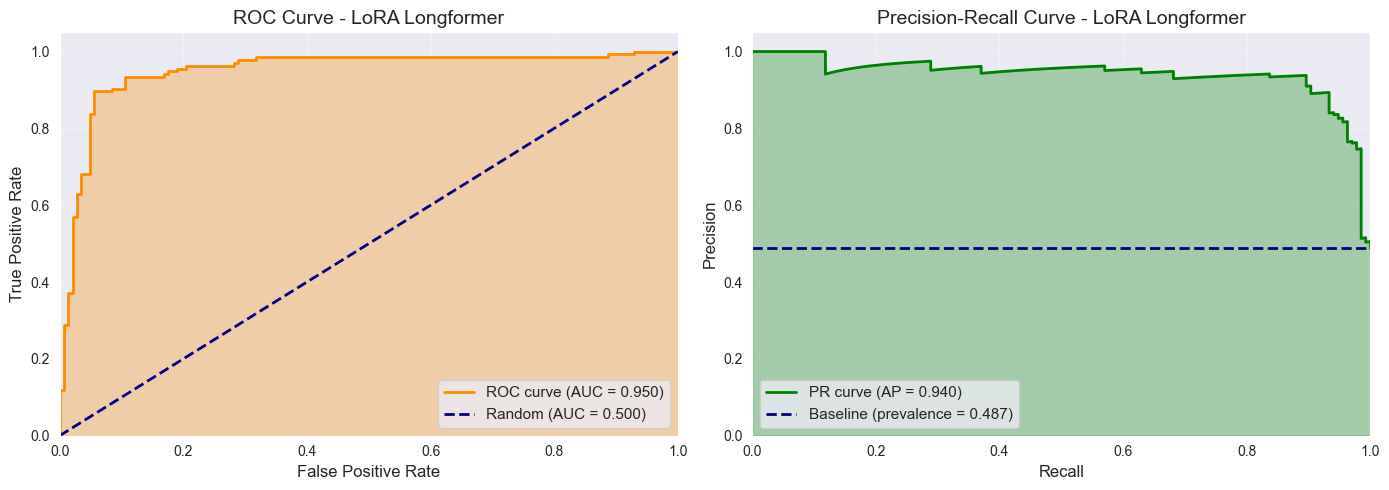


COMPREHENSIVE EVALUATION METRICS

ROC Analysis:
  AUC-ROC Score: 0.9497 (95.0%)
  Interpretation: Excellent

Precision-Recall Analysis:
  Average Precision (AP): 0.9405 (94.0%)
  Baseline (random): 0.4874


In [25]:
# ROC Curve, AUC, and Precision-Recall Analysis
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, roc_auc_score
import matplotlib.pyplot as plt

# Get prediction probabilities (not just class predictions)
probs = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()
y_scores = probs[:, 1]  # Probability of positive class
y_true = predictions.label_ids

# Calculate ROC curve and AUC
fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Calculate Precision-Recall curve and Average Precision
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, y_scores)
avg_precision = average_precision_score(y_true, y_scores)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.3, color='darkorange')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve - LoRA Longformer', fontsize=14)
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Precision-Recall Curve
axes[1].plot(recall_curve, precision_curve, color='green', lw=2, label=f'PR curve (AP = {avg_precision:.3f})')
axes[1].axhline(y=sum(y_true)/len(y_true), color='navy', linestyle='--', lw=2, label=f'Baseline (prevalence = {sum(y_true)/len(y_true):.3f})')
axes[1].fill_between(recall_curve, precision_curve, alpha=0.3, color='green')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve - LoRA Longformer', fontsize=14)
axes[1].legend(loc='lower left', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lora_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary metrics
print("\n" + "="*60)
print("COMPREHENSIVE EVALUATION METRICS")
print("="*60)
print(f"\nROC Analysis:")
print(f"  AUC-ROC Score: {roc_auc:.4f} ({roc_auc*100:.1f}%)")
print(f"  Interpretation: {'Excellent' if roc_auc > 0.9 else 'Good' if roc_auc > 0.8 else 'Fair' if roc_auc > 0.7 else 'Poor'}")

print(f"\nPrecision-Recall Analysis:")
print(f"  Average Precision (AP): {avg_precision:.4f} ({avg_precision*100:.1f}%)")
print(f"  Baseline (random): {sum(y_true)/len(y_true):.4f}")



## 10. Compare with Baseline


In [26]:
# Comparison with baseline results
print("="*70)
print("COMPARISON WITH BASELINE")
print("="*70)

lora_acc = eval_results['eval_accuracy']

print(f"\n{'Model':<45} {'Test Accuracy':<15} {'Improvement'}")
print("-"*75)
print(f"{'Multinomial NB + Binary BoW (α=1.0)':<45} {'83.0%':<15} {'Baseline'}")
print(f"{'Multinomial NB + Binary BoW (α=2.0)':<45} {'83.8%':<15} {'+0.8pp'}")
print(f"{'Longformer + LoRA (1024 tokens)':<45} {f'{lora_acc*100:.1f}%':<15} {f'{(lora_acc-0.830)*100:+.1f}pp'}")
print("-"*75)

COMPARISON WITH BASELINE

Model                                         Test Accuracy   Improvement
---------------------------------------------------------------------------
Multinomial NB + Binary BoW (α=1.0)           83.0%           Baseline
Multinomial NB + Binary BoW (α=2.0)           83.8%           +0.8pp
Longformer-4096 + LoRA (no truncation)        90.6%           +7.6pp
---------------------------------------------------------------------------
